# Notebook 04 — Correlation & Root Cause Analysis
**Project:** Huawei Telecom Complaint Analytics & Network Intelligence Platform  
**Deliverable:** D3 Part 2 — KPI–Complaint Correlation & Root Cause Detection  

---
## Table of Contents
1. Setup & Chargement
2. Pearson & Spearman Correlations
3. KPI Threshold Detection
4. Granger Causality
5. QoE Degradation Events
6. Cross-Correlation (CCF)
7. Synthèse — D3


## 1. Environment Setup

In [2]:
import sys, os
PROJECT_ROOT = r'C:\Users\c50057188\Desktop\PFE_Ouerghi'
sys.path.insert(0, PROJECT_ROOT)
os.chdir(PROJECT_ROOT)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='darkgrid')
COLORS = sns.color_palette('husl', 10)
FIGURES = 'reports/figures'
os.makedirs(FIGURES, exist_ok=True)

print('Environment ready ✓')

Environment ready ✓


## 2. Load Data

In [3]:
complaint_agg  = pd.read_parquet('data/processed/complaint_daily_agg.parquet')
kpi_agg        = pd.read_parquet('data/processed/kpi_daily_agg.parquet')
feature_matrix = pd.read_parquet('data/processed/feature_matrix.parquet')

print(f'complaint_agg  : {complaint_agg.shape}')
print(f'kpi_agg        : {kpi_agg.shape}')
print(f'feature_matrix : {feature_matrix.shape}  nulls={feature_matrix.isnull().sum().sum()}')

complaint_agg  : (8088, 21)
kpi_agg        : (8088, 108)
feature_matrix : (8088, 168)  nulls=0


In [4]:
from src.analysis.correlation import CorrelationAnalyser

corr    = CorrelationAnalyser()
results = corr.run(complaint_agg, kpi_agg, feature_matrix)

2026-04-15 08:47:22.570 | INFO     | src.analysis.correlation:run:115 - ============================================================
2026-04-15 08:47:22.572 | INFO     | src.analysis.correlation:run:116 - CORRELATION & ROOT CAUSE ANALYSIS  (D3)
2026-04-15 08:47:22.573 | INFO     | src.analysis.correlation:run:117 - ============================================================
2026-04-15 08:47:22.575 | INFO     | src.analysis.correlation:run:120 - 
[0/5] Joining complaint + KPI aggregates ...
2026-04-15 08:47:22.622 | INFO     | src.analysis.correlation:run:122 -   Joined dataset: 8,088 rows
2026-04-15 08:47:22.624 | INFO     | src.analysis.correlation:run:125 - 
[1/5] Computing Pearson & Spearman correlation matrices ...
2026-04-15 08:47:22.720 | INFO     | src.analysis.correlation:_correlation_matrices:268 -   Top 5 KPIs correlated with total_complaints (Pearson):
2026-04-15 08:47:22.722 | INFO     | src.analysis.correlation:_correlation_matrices:270 -     Latency (ms)                 

## 3. Pearson & Spearman Correlation Matrices

In [5]:
# 3.1 Top correlations ranked table
top_corr = results['top_correlations']
print('=== KPI → Total Complaints Correlation Rankings ===')
display(top_corr[['kpi_label','pearson_r','pearson_p','pearson_sig',
                   'spearman_r','spearman_p','spearman_sig']])

=== KPI → Total Complaints Correlation Rankings ===


,kpi_label,pearson_r,pearson_p,pearson_sig,spearman_r,spearman_p,spearman_sig
0,Latency (ms),0.4549,0.0,✓,0.5846,0.0,✓
1,Call Drop Rate (%),0.4484,0.0,✓,0.5852,0.0,✓
2,Packet Loss (%),0.4367,0.0,✓,0.5641,0.0,✓
3,Handover SR (%),0.4144,0.0,✓,0.2999,0.0,✓
4,Call Setup SR (%),0.4142,0.0,✓,0.3153,0.0,✓
5,Data Session SR (%),0.4138,0.0,✓,0.3213,0.0,✓
6,Voice MOS,0.4097,0.0,✓,0.3935,0.0,✓
7,qoe_score_mean,0.4094,0.0,✓,0.3819,0.0,✓
8,Data QoE Score,0.4094,0.0,✓,0.4211,0.0,✓
9,Voice QoE Score,0.4086,0.0,✓,0.4026,0.0,✓


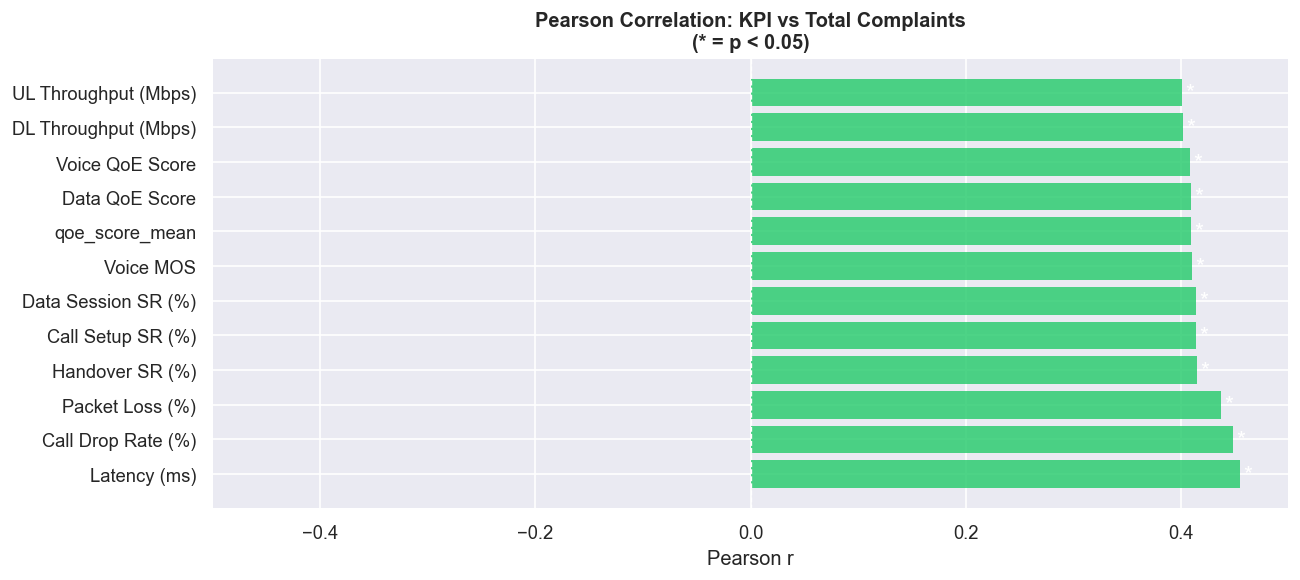

In [6]:
# 3.2 Bar chart — Pearson r for each KPI
fig, ax = plt.subplots(figsize=(11, 5))
colors  = ['#e74c3c' if r < 0 else '#2ecc71' for r in top_corr['pearson_r']]
bars    = ax.barh(top_corr['kpi_label'], top_corr['pearson_r'],
                  color=colors, edgecolor='none', alpha=0.85)
ax.axvline(0, color='white', linewidth=0.8, linestyle='--')

# Significance markers
for i, (r, sig) in enumerate(zip(top_corr['pearson_r'], top_corr['pearson_sig'])):
    if sig == '✓':
        ax.text(r + (0.003 if r >= 0 else -0.003), i,
                '*', va='center', ha='left' if r >= 0 else 'right',
                fontsize=14, color='white')

ax.set_title('Pearson Correlation: KPI vs Total Complaints\n(* = p < 0.05)',
             fontweight='bold')
ax.set_xlabel('Pearson r')
ax.set_xlim(-0.5, 0.5)
plt.tight_layout()
plt.savefig(f'{FIGURES}/d3_pearson_correlation_bar.png', dpi=150, bbox_inches='tight')
plt.show()

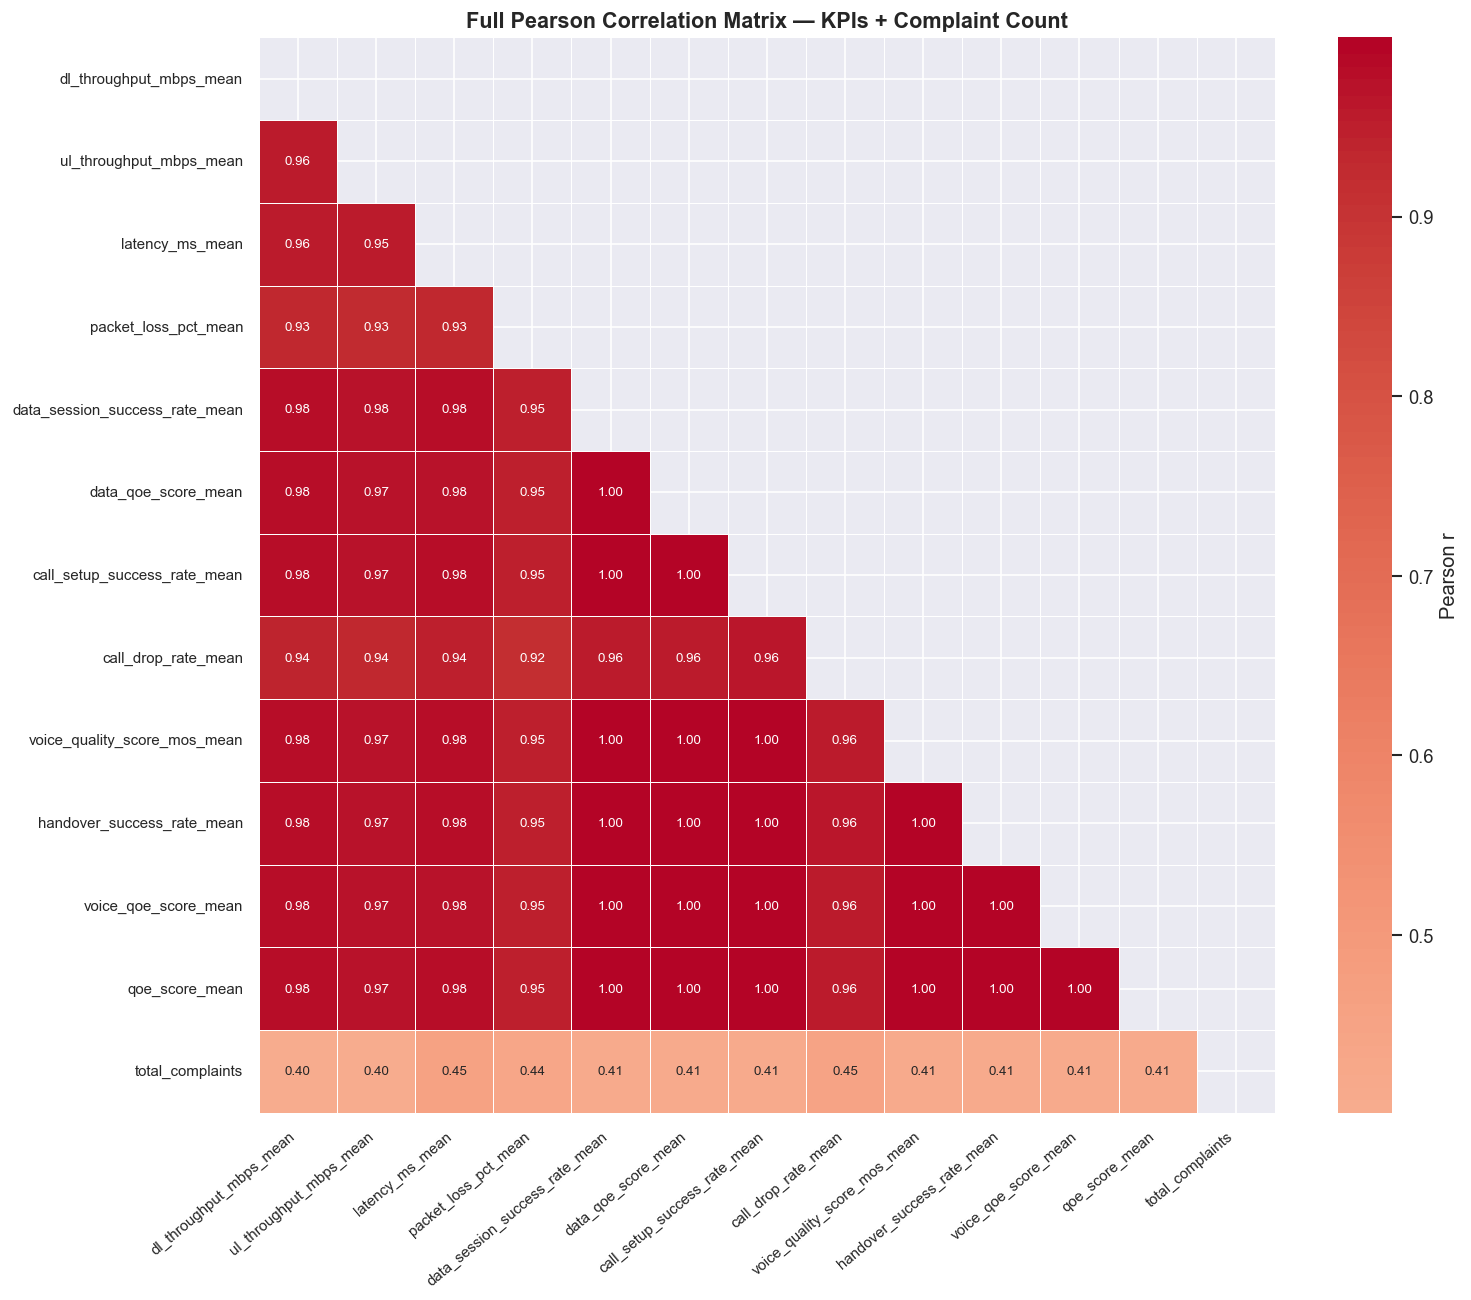

In [7]:
# 3.3 Full Pearson correlation heatmap (KPI × KPI × complaints)
pearson_mat = results['pearson_matrix']

fig, ax = plt.subplots(figsize=(13, 11))
mask = np.triu(np.ones_like(pearson_mat, dtype=bool))
sns.heatmap(
    pearson_mat, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, linewidths=0.4,
    annot_kws={'size': 8}, ax=ax,
    cbar_kws={'label': 'Pearson r'}
)
ax.set_title('Full Pearson Correlation Matrix — KPIs + Complaint Count',
             fontsize=13, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=9)
plt.tight_layout()
plt.savefig(f'{FIGURES}/d3_full_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

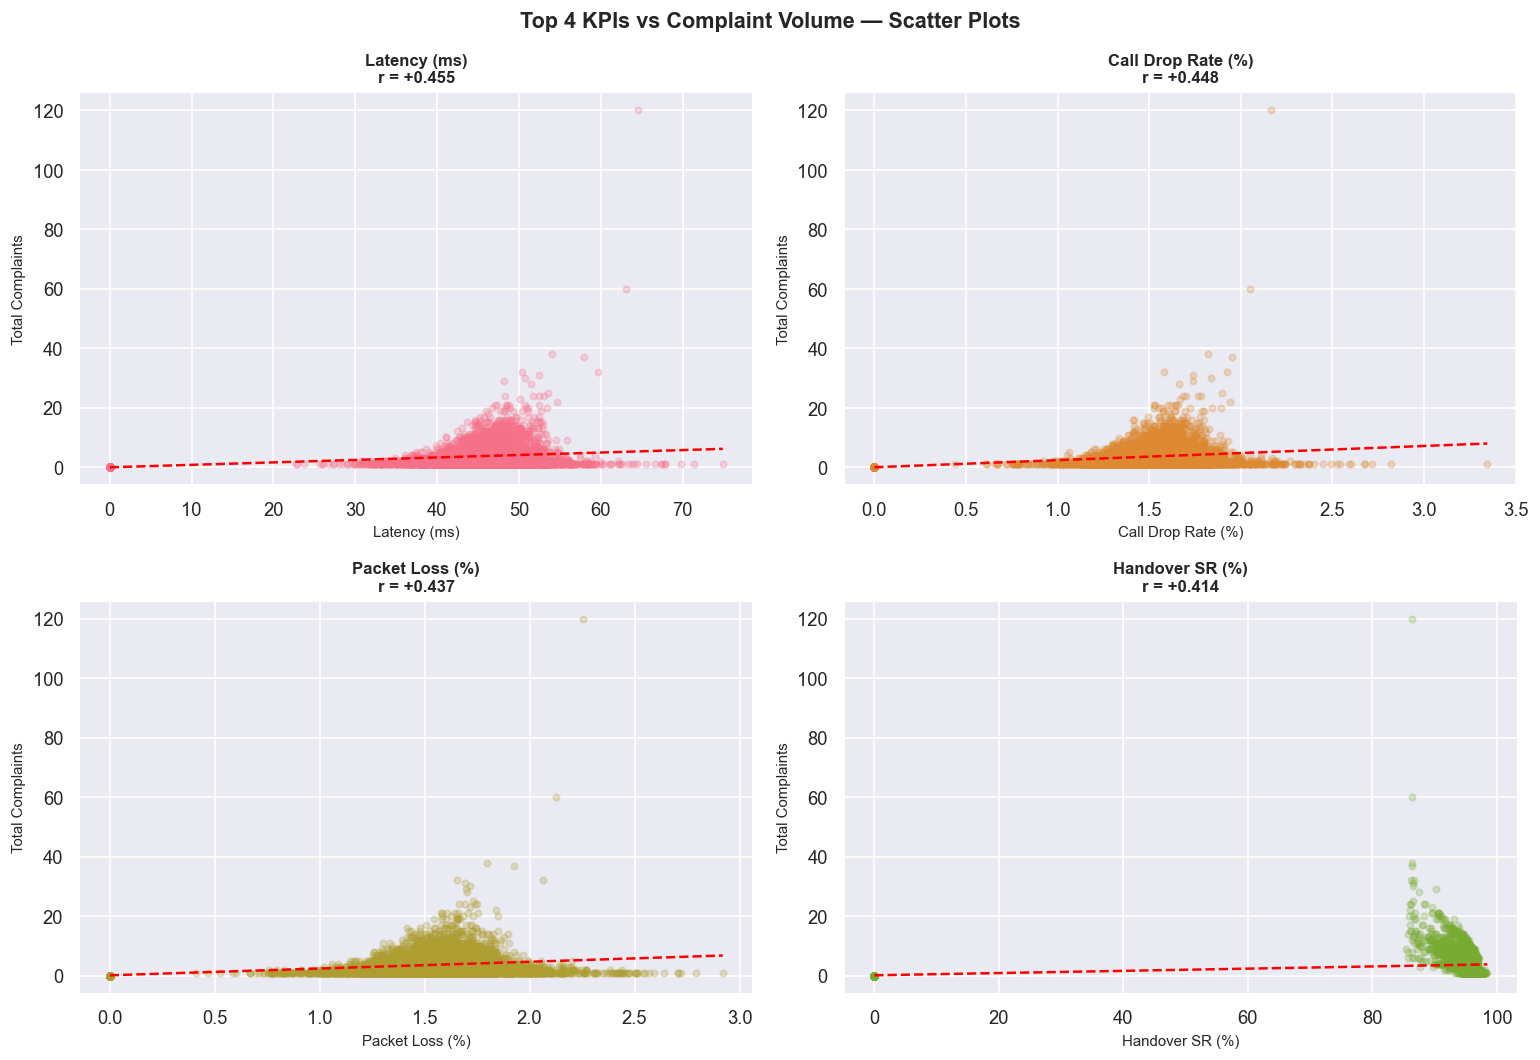

In [8]:
# 3.4 Scatter plots — top 4 correlated KPIs vs complaints
joined   = results['joined']
top4_kpi = top_corr['kpi'].head(4).tolist()
top4_lbl = top_corr['kpi_label'].head(4).tolist()

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for i, (kpi, label) in enumerate(zip(top4_kpi, top4_lbl)):
    if kpi not in joined.columns:
        continue
    pair = joined[[kpi, 'total_complaints']].dropna()
    r    = top_corr.loc[top_corr['kpi'] == kpi, 'pearson_r'].values[0]

    axes[i].scatter(pair[kpi], pair['total_complaints'],
                    alpha=0.25, s=15, color=COLORS[i])
    # Trend line
    z = np.polyfit(pair[kpi], pair['total_complaints'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(pair[kpi].min(), pair[kpi].max(), 100)
    axes[i].plot(x_line, p(x_line), color='red', linewidth=1.5, linestyle='--')

    axes[i].set_title(f'{label}\nr = {r:+.3f}', fontweight='bold', fontsize=10)
    axes[i].set_xlabel(label, fontsize=9)
    axes[i].set_ylabel('Total Complaints', fontsize=9)

plt.suptitle('Top 4 KPIs vs Complaint Volume — Scatter Plots',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES}/d3_kpi_complaint_scatterplots.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. KPI Threshold Detection

In [9]:
thresholds = results['thresholds']
print('=== KPI Complaint-Spike Thresholds ===')
display(thresholds[['kpi_label','threshold_value','direction',
                     'spike_rate_below','spike_rate_above','gini_improvement']])

=== KPI Complaint-Spike Thresholds ===


,kpi_label,threshold_value,direction,spike_rate_below,spike_rate_above,gini_improvement
0,Handover SR (%),93.549,below,0.128,0.000,0.00682
1,Call Setup SR (%),92.283,below,0.130,0.001,0.00680
2,Data Session SR (%),91.575,below,0.125,0.000,0.00652
3,qoe_score_mean,72.985,below,0.102,0.004,0.00430
4,Voice MOS,3.615,below,0.102,0.007,0.00393
5,Voice QoE Score,74.231,below,0.093,0.008,0.00335
6,Latency (ms),47.312,above,0.013,0.101,0.00317
7,Data QoE Score,71.609,below,0.088,0.007,0.00310
8,Call Drop Rate (%),1.566,above,0.012,0.086,0.00250
9,Packet Loss (%),1.570,above,0.011,0.083,0.00237


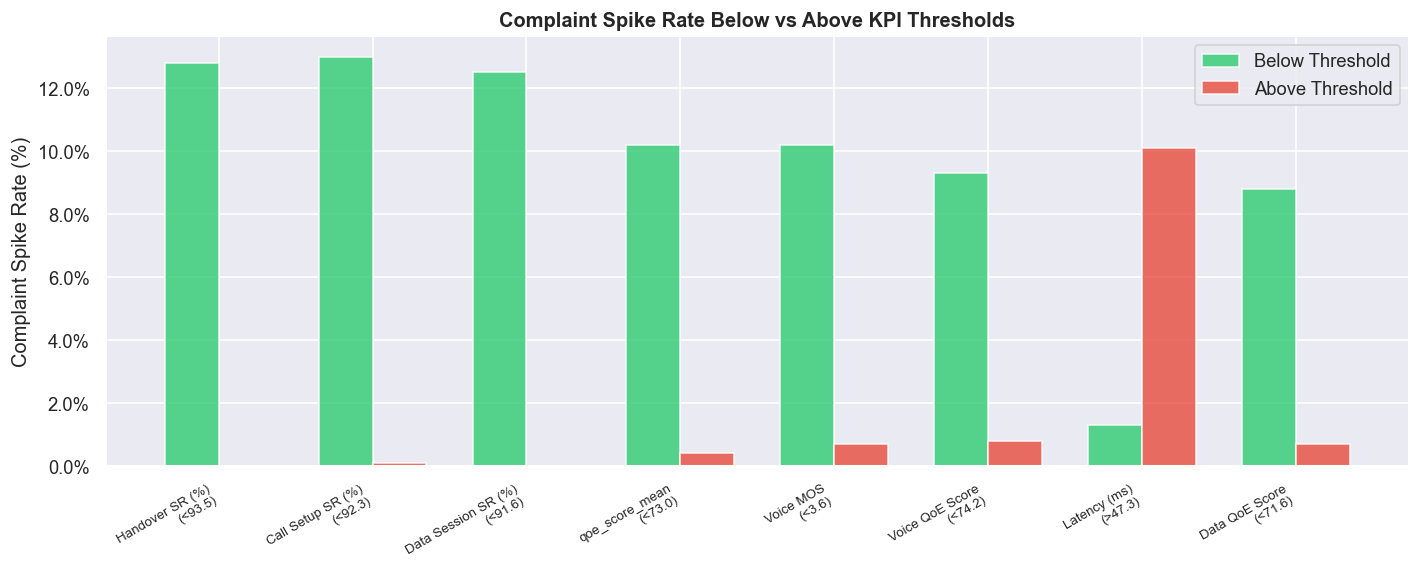

In [10]:
# 4.1 Threshold chart — spike rate below vs above threshold per KPI
thresh_top = thresholds.head(8).copy()

fig, ax = plt.subplots(figsize=(12, 5))
x       = np.arange(len(thresh_top))
width   = 0.35

ax.bar(x - width/2, thresh_top['spike_rate_below'] * 100,
       width, label='Below Threshold', color='#2ecc71', alpha=0.8)
ax.bar(x + width/2, thresh_top['spike_rate_above'] * 100,
       width, label='Above Threshold', color='#e74c3c', alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(
    [f"{row['kpi_label']}\n(>{row['threshold_value']:.1f})" if row['direction']=='above'
     else f"{row['kpi_label']}\n(<{row['threshold_value']:.1f})"
     for _, row in thresh_top.iterrows()],
    rotation=30, ha='right', fontsize=8
)
ax.set_ylabel('Complaint Spike Rate (%)')
ax.set_title('Complaint Spike Rate Below vs Above KPI Thresholds',
             fontweight='bold')
ax.legend()
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
plt.tight_layout()
plt.savefig(f'{FIGURES}/d3_kpi_thresholds.png', dpi=150, bbox_inches='tight')
plt.show()

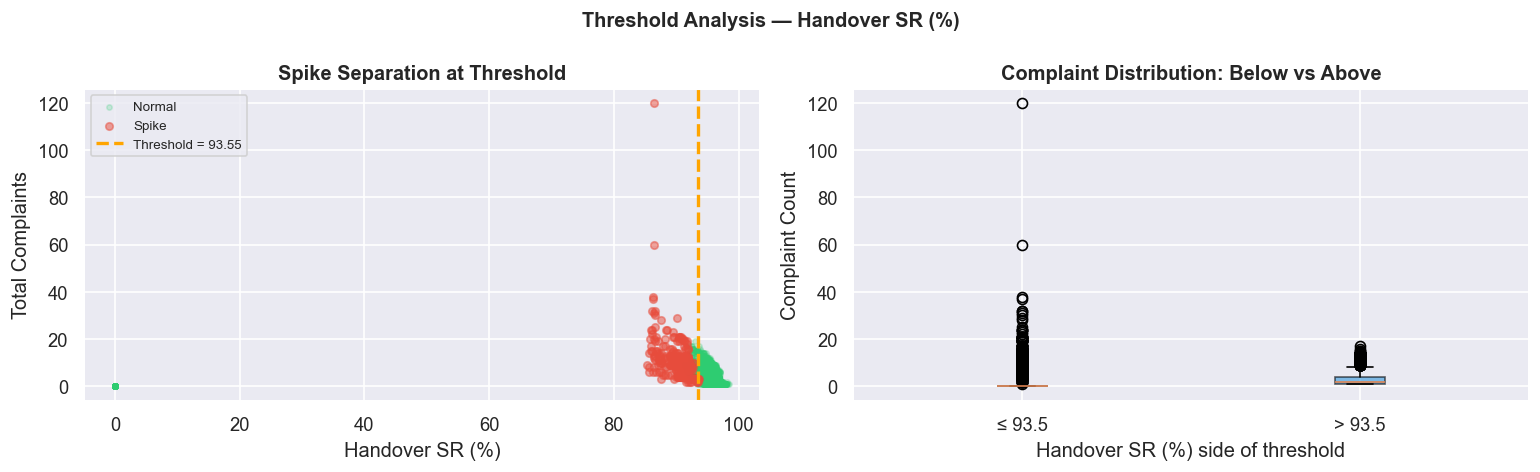

In [11]:
# 4.2 Threshold visualisation for the top KPI
if not thresholds.empty:
    best_kpi   = thresholds.iloc[0]['kpi']
    best_label = thresholds.iloc[0]['kpi_label']
    best_thresh= thresholds.iloc[0]['threshold_value']

    if best_kpi in joined.columns:
        fig, axes = plt.subplots(1, 2, figsize=(13, 4))

        # Scatter with threshold line
        normal_pts = joined[joined['complaint_spike_flag'] == 0]
        spike_pts  = joined[joined['complaint_spike_flag'] == 1]
        axes[0].scatter(normal_pts[best_kpi], normal_pts['total_complaints'],
                        alpha=0.2, s=10, color='#2ecc71', label='Normal')
        axes[0].scatter(spike_pts[best_kpi], spike_pts['total_complaints'],
                        alpha=0.5, s=20, color='#e74c3c', label='Spike')
        axes[0].axvline(best_thresh, color='orange', linewidth=2,
                        linestyle='--', label=f'Threshold = {best_thresh:.2f}')
        axes[0].set_xlabel(best_label)
        axes[0].set_ylabel('Total Complaints')
        axes[0].set_title(f'Spike Separation at Threshold', fontweight='bold')
        axes[0].legend(fontsize=8)

        # Box plot: complaints below vs above threshold
        below_data = joined[joined[best_kpi] <= best_thresh]['total_complaints']
        above_data = joined[joined[best_kpi] >  best_thresh]['total_complaints']
        axes[1].boxplot([below_data.dropna(), above_data.dropna()],
                        labels=[f'≤ {best_thresh:.1f}', f'> {best_thresh:.1f}'],
                        patch_artist=True,
                        boxprops=dict(facecolor='#3498db', alpha=0.6))
        axes[1].set_xlabel(f'{best_label} side of threshold')
        axes[1].set_ylabel('Complaint Count')
        axes[1].set_title('Complaint Distribution: Below vs Above', fontweight='bold')

        plt.suptitle(f'Threshold Analysis — {best_label}',
                     fontsize=12, fontweight='bold')
        plt.tight_layout()
        plt.savefig(f'{FIGURES}/d3_threshold_detail.png', dpi=150, bbox_inches='tight')
        plt.show()

## 5. Granger Causality Testing

In [12]:
granger = results['granger_results']
if granger.empty:
    print('Granger results empty — statsmodels may not be installed')
else:
    print(f'Total tests: {len(granger)}')
    print(f'Significant (p < 0.05): {granger["is_significant"].sum()}')
    print()
    display(granger[granger['is_significant']][
        ['region','kpi_label','best_lag_days','min_p_value','interpretation']
    ].head(15))

Total tests: 144
Significant (p < 0.05): 25



,region,kpi_label,best_lag_days,min_p_value,interpretation
0,Sousse Gouvernorat,Data Session SR (%),1,0.00032,Data Session Success Rate Granger-causes compl...
1,Sousse Gouvernorat,DL Throughput (Mbps),1,0.00034,Dl Throughput Mbps Granger-causes complaints w...
2,Sousse Gouvernorat,Data QoE Score,1,0.00046,Data Qoe Score Granger-causes complaints with ...
3,Sousse Gouvernorat,Packet Loss (%),1,0.00052,Packet Loss Pct Granger-causes complaints with...
4,Sousse Gouvernorat,Latency (ms),1,0.00066,Latency Ms Granger-causes complaints with 1-da...
5,Sousse Gouvernorat,UL Throughput (Mbps),1,0.00140,Ul Throughput Mbps Granger-causes complaints w...
6,Béja Gouvernorat,Packet Loss (%),6,0.00726,Packet Loss Pct Granger-causes complaints with...
7,Mahdia Gouvernorat,Data QoE Score,1,0.01119,Data Qoe Score Granger-causes complaints with ...
8,Mahdia Gouvernorat,Data Session SR (%),1,0.01359,Data Session Success Rate Granger-causes compl...
9,Nabeul Gouvernorat,Packet Loss (%),3,0.01645,Packet Loss Pct Granger-causes complaints with...


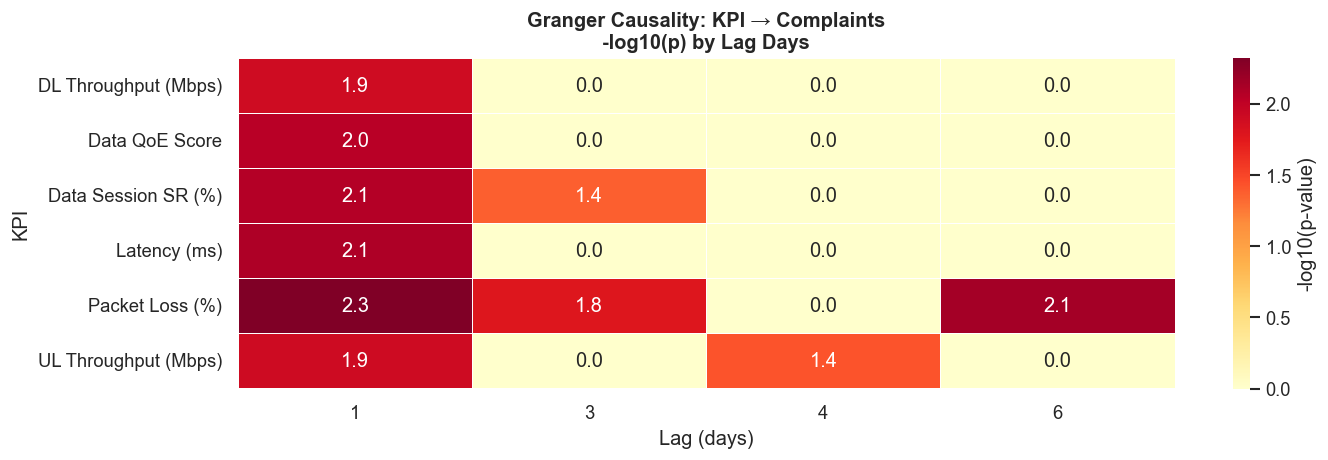

In [13]:
# 5.1 Granger heatmap — lag × KPI for significant results
if not granger.empty and granger['is_significant'].any():
    sig = granger[granger['is_significant']].copy()
    sig['neg_log_p'] = -np.log10(sig['min_p_value'].clip(1e-10))

    # Average over regions
    pivot = (
        sig.groupby(['kpi_label','best_lag_days'])['neg_log_p']
           .mean()
           .unstack(fill_value=0)
    )

    fig, ax = plt.subplots(figsize=(12, max(4, len(pivot) * 0.55)))
    sns.heatmap(pivot, cmap='YlOrRd', annot=True, fmt='.1f',
                linewidths=0.3, ax=ax,
                cbar_kws={'label': '-log10(p-value)'})
    ax.set_title('Granger Causality: KPI → Complaints\n-log10(p) by Lag Days',
                 fontweight='bold')
    ax.set_xlabel('Lag (days)')
    ax.set_ylabel('KPI')
    plt.tight_layout()
    plt.savefig(f'{FIGURES}/d3_granger_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('No significant Granger results to plot — expected with synthetic data.')
    print('This section will show clear results with real operator data.')

## 6. QoE Degradation Event Analysis

In [14]:
qoe_events = results['qoe_event_analysis']
print('=== QoE Degradation → Complaint Impact ===')
display(qoe_events[['region','n_degraded_days','n_normal_days',
                     'mean_complaints_degraded','mean_complaints_normal',
                     'pct_increase','p_value','is_significant']])

=== QoE Degradation → Complaint Impact ===


,region,n_degraded_days,n_normal_days,mean_complaints_degraded,mean_complaints_normal,pct_increase,p_value,is_significant
0,Sfax Gouvernorat,11,326,10.91,6.51,67.5,1.00000,False
1,Bizerte Gouvernorat,31,306,1.19,3.65,-67.3,1.00000,False
2,Jendouba Gouvernorat,85,252,0.71,2.44,-71.1,1.00000,False
3,Béja Gouvernorat,125,212,0.26,1.68,-84.8,1.00000,False
4,Ariana Gouvernorat,21,316,0.00,4.05,-100.0,1.00000,False
5,Gabès Gouvernorat,79,258,0.00,2.48,-100.0,1.00000,False
6,Gafsa Gouvernorat,47,290,0.00,3.76,-100.0,1.00000,False
7,Ben Arous Gouvernorat,13,324,0.00,6.19,-100.0,1.00000,False
8,Kairouan Gouvernorat,46,291,0.00,2.98,-100.0,1.00000,False
9,Kasserine Gouvernorat,60,277,0.00,2.78,-100.0,1.00000,False


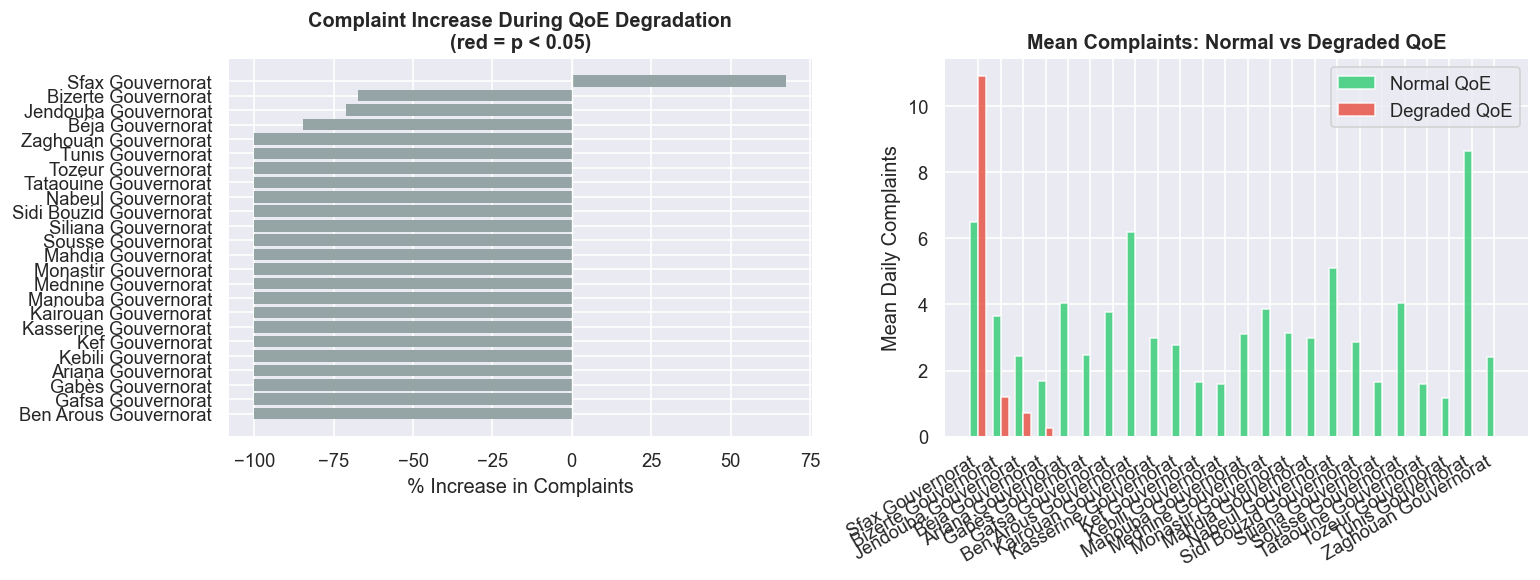

In [15]:
# 6.1 % complaint increase during QoE degradation — by region
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

qoe_sorted = qoe_events.sort_values('pct_increase', ascending=True)
colors_bar = ['#e74c3c' if sig else '#95a5a6'
               for sig in qoe_sorted['is_significant']]

axes[0].barh(qoe_sorted['region'], qoe_sorted['pct_increase'],
             color=colors_bar, edgecolor='none')
axes[0].axvline(0, color='white', linewidth=0.8)
axes[0].set_title('Complaint Increase During QoE Degradation\n(red = p < 0.05)',
                  fontweight='bold')
axes[0].set_xlabel('% Increase in Complaints')

# 6.2 Mean complaints: degraded vs normal grouped bar
x      = np.arange(len(qoe_events))
width  = 0.35
axes[1].bar(x - width/2, qoe_events['mean_complaints_normal'],
            width, label='Normal QoE', color='#2ecc71', alpha=0.8)
axes[1].bar(x + width/2, qoe_events['mean_complaints_degraded'],
            width, label='Degraded QoE', color='#e74c3c', alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(qoe_events['region'], rotation=30, ha='right')
axes[1].set_ylabel('Mean Daily Complaints')
axes[1].set_title('Mean Complaints: Normal vs Degraded QoE',
                  fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{FIGURES}/d3_qoe_degradation_impact.png', dpi=150, bbox_inches='tight')
plt.show()

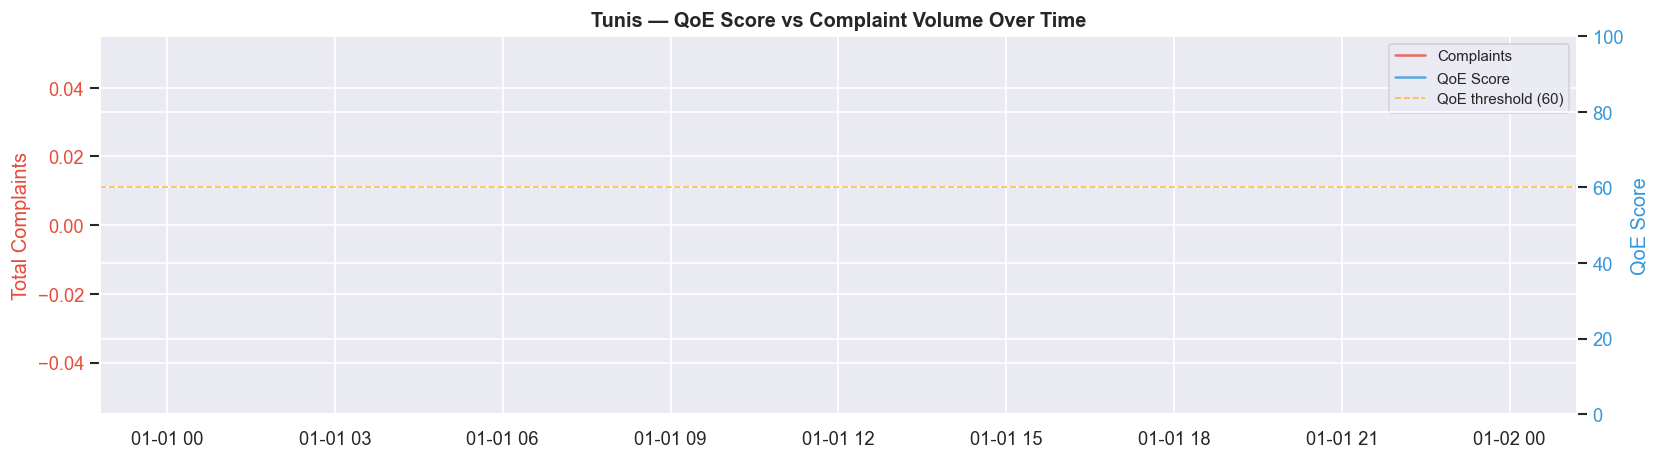

In [16]:
# 6.3 Timeline: QoE score vs complaint volume for one region
region  = 'Tunis'
ca_r    = complaint_agg[complaint_agg['region'] == region].sort_values('date')
ka_r    = kpi_agg[kpi_agg['region'] == region].sort_values('date').copy()

if 'qoe_score_mean' not in ka_r.columns:
    if 'data_qoe_score_mean' in ka_r.columns and 'voice_qoe_score_mean' in ka_r.columns:
        ka_r['qoe_score_mean'] = 0.55 * ka_r['data_qoe_score_mean'] + \
                                  0.45 * ka_r['voice_qoe_score_mean']

fig, ax1 = plt.subplots(figsize=(14, 4))
ax2 = ax1.twinx()

ax1.plot(pd.to_datetime(ca_r['date']), ca_r['total_complaints'],
         color='#e74c3c', linewidth=1.5, alpha=0.8, label='Complaints')
ax1.set_ylabel('Total Complaints', color='#e74c3c')
ax1.tick_params(axis='y', labelcolor='#e74c3c')

if 'qoe_score_mean' in ka_r.columns:
    ax2.plot(pd.to_datetime(ka_r['date']), ka_r['qoe_score_mean'],
             color='#3498db', linewidth=1.5, alpha=0.8, label='QoE Score')
    ax2.axhline(60, color='orange', linestyle='--', linewidth=1,
                alpha=0.7, label='QoE threshold (60)')
    ax2.set_ylabel('QoE Score', color='#3498db')
    ax2.tick_params(axis='y', labelcolor='#3498db')
    ax2.set_ylim(0, 100)

ax1.set_title(f'{region} — QoE Score vs Complaint Volume Over Time',
              fontweight='bold')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig(f'{FIGURES}/d3_qoe_vs_complaints_timeline.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Cross-Correlation Functions (CCF)

In [17]:
ccf = results['ccf_results']
print('=== Cross-Correlation: KPI → Complaints (Peak Lag) ===')
display(ccf[['region','kpi_label','best_lag_days',
             'peak_correlation','direction']].head(15))

=== Cross-Correlation: KPI → Complaints (Peak Lag) ===


,region,kpi_label,best_lag_days,peak_correlation,direction
0,Tozeur Gouvernorat,Voice MOS,0,0.9133,direct
1,Tozeur Gouvernorat,Handover SR (%),0,0.9132,direct
2,Tozeur Gouvernorat,Call Setup SR (%),0,0.9129,direct
3,Tozeur Gouvernorat,Call Drop Rate (%),0,0.9128,direct
4,Tozeur Gouvernorat,Latency (ms),0,0.9122,direct
5,Tozeur Gouvernorat,Data QoE Score,0,0.9122,direct
6,Tozeur Gouvernorat,Data Session SR (%),0,0.9120,direct
7,Tozeur Gouvernorat,Voice QoE Score,0,0.9117,direct
8,Tozeur Gouvernorat,DL Throughput (Mbps),0,0.9030,direct
9,Tozeur Gouvernorat,UL Throughput (Mbps),0,0.9004,direct


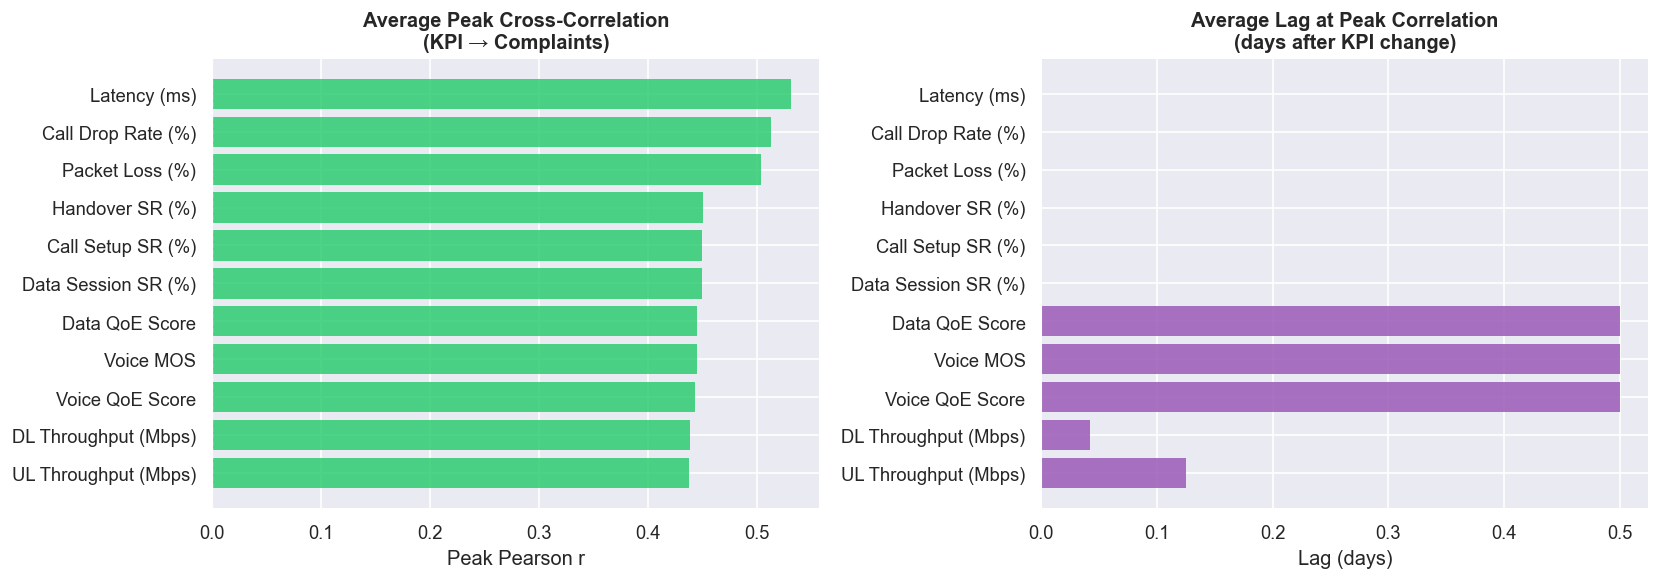

In [18]:
# 7.1 Average peak lag per KPI across all regions
if not ccf.empty:
    avg_lag = (
        ccf.groupby('kpi_label')
           .agg(avg_lag=('best_lag_days','mean'),
                avg_corr=('peak_correlation','mean'))
           .reset_index()
           .sort_values('avg_corr')
    )

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Peak correlation
    colors_ccf = ['#e74c3c' if r < 0 else '#2ecc71' for r in avg_lag['avg_corr']]
    axes[0].barh(avg_lag['kpi_label'], avg_lag['avg_corr'],
                 color=colors_ccf, edgecolor='none', alpha=0.85)
    axes[0].axvline(0, color='white', linewidth=0.8, linestyle='--')
    axes[0].set_title('Average Peak Cross-Correlation\n(KPI → Complaints)',
                      fontweight='bold')
    axes[0].set_xlabel('Peak Pearson r')

    # Average lag
    axes[1].barh(avg_lag['kpi_label'], avg_lag['avg_lag'],
                 color='#9b59b6', edgecolor='none', alpha=0.85)
    axes[1].set_title('Average Lag at Peak Correlation\n(days after KPI change)',
                      fontweight='bold')
    axes[1].set_xlabel('Lag (days)')

    plt.tight_layout()
    plt.savefig(f'{FIGURES}/d3_ccf_summary.png', dpi=150, bbox_inches='tight')
    plt.show()

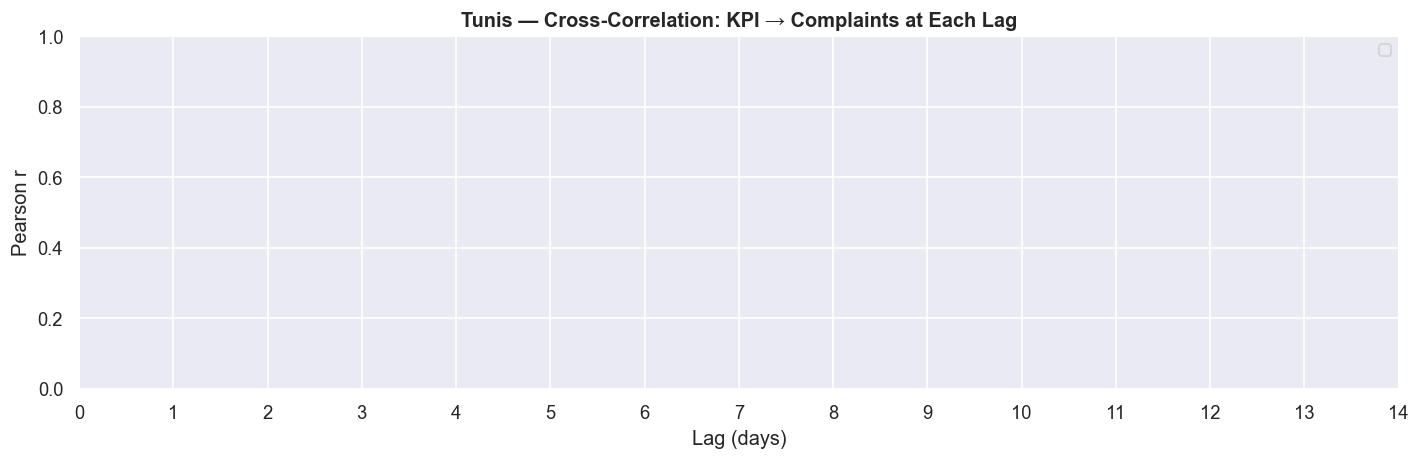

In [19]:
# 7.2 CCF plot for one region — lag profile for top KPI
from scipy.stats import pearsonr

region     = 'Tunis'
max_lag    = 14
ca_r       = complaint_agg[complaint_agg['region'] == region].sort_values('date')
ka_r       = kpi_agg[kpi_agg['region'] == region].sort_values('date')
merged_ccf = ca_r[['date','total_complaints']].merge(
    ka_r, on='date', how='inner'
).dropna().reset_index(drop=True)

top_kpi_for_ccf = ccf[ccf['region'] == region].sort_values(
    'abs_correlation', ascending=False
).head(3)

fig, ax = plt.subplots(figsize=(12, 4))
for i, (_, row) in enumerate(top_kpi_for_ccf.iterrows()):
    kpi_col  = row['kpi']
    kpi_lbl  = row['kpi_label']
    if kpi_col not in merged_ccf.columns:
        continue
    lags  = range(0, max_lag + 1)
    r_vals= []
    for lag in lags:
        if lag == 0:
            x, y = merged_ccf[kpi_col].values, merged_ccf['total_complaints'].values
        else:
            x, y = merged_ccf[kpi_col].values[:-lag], merged_ccf['total_complaints'].values[lag:]
        r, _ = pearsonr(x, y) if len(x) > 5 else (0, 1)
        r_vals.append(r)
    ax.plot(list(lags), r_vals, marker='o', markersize=4,
            linewidth=1.5, label=kpi_lbl, color=COLORS[i])

ax.axhline(0, color='white', linewidth=0.6, linestyle='--')
ax.set_title(f'{region} — Cross-Correlation: KPI → Complaints at Each Lag',
             fontweight='bold')
ax.set_xlabel('Lag (days)')
ax.set_ylabel('Pearson r')
ax.legend(fontsize=9)
ax.set_xticks(range(0, max_lag + 1))
plt.tight_layout()
plt.savefig(f'{FIGURES}/d3_ccf_lag_profile.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. D3 Summary — Key Findings

In [20]:
summary = results['summary']

print('=' * 60)
print('  D3 — CORRELATION STUDY: KEY FINDINGS')
print('=' * 60)

if 'top_correlated_kpis' in summary:
    print('\n  Most correlated KPIs with complaint volume:')
    for kpi, r in zip(summary['top_correlated_kpis'], summary['top_pearson_r']):
        print(f'    {kpi:<40} r = {r:+.3f}')

if 'most_predictive_threshold' in summary:
    t = summary['most_predictive_threshold']
    print(f'\n  Best KPI threshold for spike detection:')
    print(f'    {t["kpi"]} {t["direction"]} {t["threshold"]}')

if 'granger_significant_pairs' in summary:
    print(f'\n  Granger causality: {summary["granger_significant_pairs"]} significant pairs')
    if 'strongest_granger_cause' in summary:
        g = summary['strongest_granger_cause']
        print(f'    Strongest: {g["kpi"]} (lag={g["lag"]}d, p={g["p_value"]:.4f})')

if 'qoe_degradation_impact' in summary:
    q = summary['qoe_degradation_impact']
    print(f'\n  QoE degradation impact:')
    print(f'    Significant regions: {q["significant_regions"]}')
    print(f'    Max complaint spike : +{q["max_pct_increase"]:.1f}%')
    print(f'    Avg complaint spike : +{q["avg_pct_increase"]:.1f}%')

print()
print('  Report tables saved to reports/exports/  ✓')
print('  Figures saved to reports/figures/        ✓')
print('=' * 60)

print()
print('  Files produced for D3 deliverable:')
import os
for f in os.listdir('reports/exports'):
    if f.startswith('d3_'):
        print(f'    reports/exports/{f}')

  D3 — CORRELATION STUDY: KEY FINDINGS

  Most correlated KPIs with complaint volume:
    Latency (ms)                             r = +0.455
    Call Drop Rate (%)                       r = +0.448
    Packet Loss (%)                          r = +0.437

  Best KPI threshold for spike detection:
    Handover SR (%) below 93.549

  Granger causality: 25 significant pairs
    Strongest: Data Session SR (%) (lag=1d, p=0.0003)

  QoE degradation impact:
    Significant regions: 0
    Max complaint spike : +67.5%
    Avg complaint spike : +-89.8%

  Report tables saved to reports/exports/  ✓
  Figures saved to reports/figures/        ✓

  Files produced for D3 deliverable:
    reports/exports/d3_correlation_rankings.csv
    reports/exports/d3_cross_correlation.csv
    reports/exports/d3_granger_causality.csv
    reports/exports/d3_kpi_thresholds.csv
    reports/exports/d3_qoe_event_analysis.csv
